# Import potrzebnych bibliotek

In [13]:
import pandas as pd
import requests
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytanie pliku danych o cenach nieruchomości w USA i wyświetlenie pierwszych 5 rekordów

In [14]:
df_housing = pd.read_csv('Housing.csv')

df_housing.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Opis wszystkich kolumn w pliku

|     | nazwa kolumny    | typ      | opis                         |
|-----|------------------|----------|------------------------------|
| 1.  | price            | liczbowy | cena (domyślnie w USD)       |
| 2.  | area             | liczbowy | powierzchnia                 |
| 3.  | bedrooms         | liczbowy | ilość sypialni               |
| 4.  | bathrooms        | liczbowy | ilość łazienek               |
| 5.  | stories          | liczbowy | ilość pięter                 |
| 6.  | mainroad         | opisowy  | czy leży przy głownej ulicy  |
| 7.  | guestroom        | opisowy  | czy ma pokój dla gości       |
| 8.  | basement         | opisowy  | czy ma piwnicę               |
| 9.  | hotwoterheating  | opisowy  | czy ma bojler                |
| 10. | aircondiotioning | opisowy  | czy ma klimatyzację          |
| 11. | parking          | liczbowy | ile miejsc parkingowych      |
| 12. | prefarea         | opisowy  | czy okolica jest pożądana    |
| 13. | furnishingstatus | opisowy  | jaki jest status umeblowania |

# Pobieranie aktualnego kursu dolar-złotówka bezpośrednio z API NBP

In [15]:
url = "https://api.nbp.pl/api/exchangerates/rates/A/USD/?format=json"

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    current_usd_rate = data['rates'][0]['mid']
    print(status := f"Aktualny kurs USD: {current_usd_rate} PLN")
else:
    print(f"Błąd pobierania danych z API. Status code: {response.status_code}")

Aktualny kurs USD: 3.6529 PLN


# Przeliczenie ceny nieruchmości z USD na PLN oraz wyświetlenie pierwszych 5 rekordów z nową tabelą

In [16]:
df_housing['price_PLN'] = df_housing['price'] * current_usd_rate

df_housing[['price', 'price_PLN', 'area', 'bedrooms']].head()

,price,price_PLN,area,bedrooms
0,13300000,48583570.0,7420,4
1,12250000,44748025.0,8960,4
2,12250000,44748025.0,9960,3
3,12215000,44620173.5,7500,4
4,11410000,41679589.0,7420,4


# Walidacja danych

In [17]:
brakujace_ceny = df_housing['price_PLN'].isnull().sum()

czy_liczba = pd.api.types.is_numeric_dtype(df_housing['price_PLN'])

wszystkie_dodatnie = (df_housing['price_PLN'] > 0).all()

print("RAPORT WALIDACJI DANYCH")
print(f"Liczba brakujących wartości w cenie PLN: {brakujace_ceny}")
print(f"Czy kolumna cenowa jest typu numerycznego?: {czy_liczba}")
print(f"Czy wszystkie ceny są większe od 0?: {wszystkie_dodatnie}")

if brakujace_ceny == 0 and czy_liczba and wszystkie_dodatnie:
    print("\nDane są poprawne.")
else:
    print("\nWykryto błędy w strukturze danych!")

RAPORT WALIDACJI DANYCH
Liczba brakujących wartości w cenie PLN: 0
Czy kolumna cenowa jest typu numerycznego?: True
Czy wszystkie ceny są większe od 0?: True

Dane są poprawne.


# Zapisanie DataFrame do formatu Pickle oraz test odczytu

In [18]:
df_housing.to_pickle('housing_integrated.pkl')

df_weryfikacja = pd.read_pickle('housing_integrated.pkl')
print(f"Weryfikacja zapisu - liczba wierszy w zapisanym pliku: {len(df_weryfikacja)}")

Weryfikacja zapisu - liczba wierszy w zapisanym pliku: 545


# Wczytanie danych z pliku Pickle

In [19]:
df_prep = pd.read_pickle('housing_integrated.pkl')
df_prep.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus,price_PLN
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished,48583570.0
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished,44748025.0
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished,44748025.0
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished,44620173.5
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished,41679589.0


# Czyszczenie i filtrowanie danych
(Usunięcie wierszy z brakami oraz wartości odstających dla kolumny area) i definicja granicy dla poprawnych wartości

In [20]:
df_prep = df_prep.dropna()

Q1 = df_prep['area'].quantile(0.25)
Q3 = df_prep['area'].quantile(0.75)
IQR = Q3 - Q1

dolna_granica = Q1 - 1.5 * IQR
gorna_granica = Q3 + 1.5 * IQR

df_clean = df_prep[(df_prep['area'] >= dolna_granica) & (df_prep['area'] <= gorna_granica)].copy()

print(f"Liczba rekordów przed usunięciem anomalii: {len(df_prep)}")
print(f"Liczba rekordów po usunięciu anomalii: {len(df_clean)}")

Liczba rekordów przed usunięciem anomalii: 545
Liczba rekordów po usunięciu anomalii: 533


# Zamiana kolum tekstowych na liczbowe (One-Hot Encoding)

In [21]:
kolumny_tekstowe = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

df_encoded = pd.get_dummies(df_clean, columns=kolumny_tekstowe, drop_first=True, dtype=int)

print("Kolumny po wykonaniu One-Hot Encoding:")
print(df_encoded.columns.tolist())
df_encoded.head()

Kolumny po wykonaniu One-Hot Encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price_PLN', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


,price,area,bedrooms,bathrooms,stories,parking,price_PLN,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,48583570.0,1,0,0,0,1,1,0,0
1,12250000,8960,4,4,4,3,44748025.0,1,0,0,0,1,0,0,0
2,12250000,9960,3,2,2,2,44748025.0,1,0,1,0,0,1,1,0
3,12215000,7500,4,2,2,3,44620173.5,1,0,1,0,1,1,0,0
4,11410000,7420,4,1,2,2,41679589.0,1,1,1,0,1,0,0,0


# Przygotowywanie danych do treningu modelu oraz skalowanie cech numerycznych
X- wszystkie cechy oprócz cen

Y- cena w PLN

In [22]:
X = df_encoded.drop(columns=['price', 'price_PLN'])

y = df_encoded['price_PLN']

scaler = StandardScaler()

X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled.head()

,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,1.316021,1.413578,1.426798,1.367607,1.531554,0.410925,-0.468700,-0.732136,-0.217143,1.467599,1.835443,-0.848148,-0.702138
1,2.146871,1.413578,5.429342,2.515536,2.696059,0.410925,-0.468700,-0.732136,-0.217143,1.467599,-0.544827,-0.848148,-0.702138
2,2.686383,0.053583,1.426798,0.219679,1.531554,0.410925,-0.468700,1.365867,-0.217143,-0.681385,1.835443,1.179040,-0.702138
3,1.359182,1.413578,1.426798,0.219679,2.696059,0.410925,-0.468700,1.365867,-0.217143,1.467599,1.835443,-0.848148,-0.702138
4,1.316021,1.413578,-0.574474,0.219679,1.531554,0.410925,2.133561,1.365867,-0.217143,1.467599,-0.544827,-0.848148,-0.702138


# Podział danych na zbiór treningowy i zbiór testowy oraz trening modelu
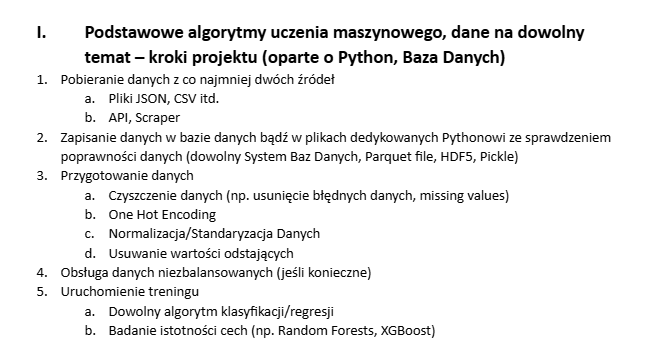

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_split=5, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Skuteczność modelu (R^2 Score): {r2_score(y_test, y_pred):.2f}\n")

Skuteczność modelu (R^2 Score): 0.55



# Badanie, które cechy najbardziej wpływają na cenę

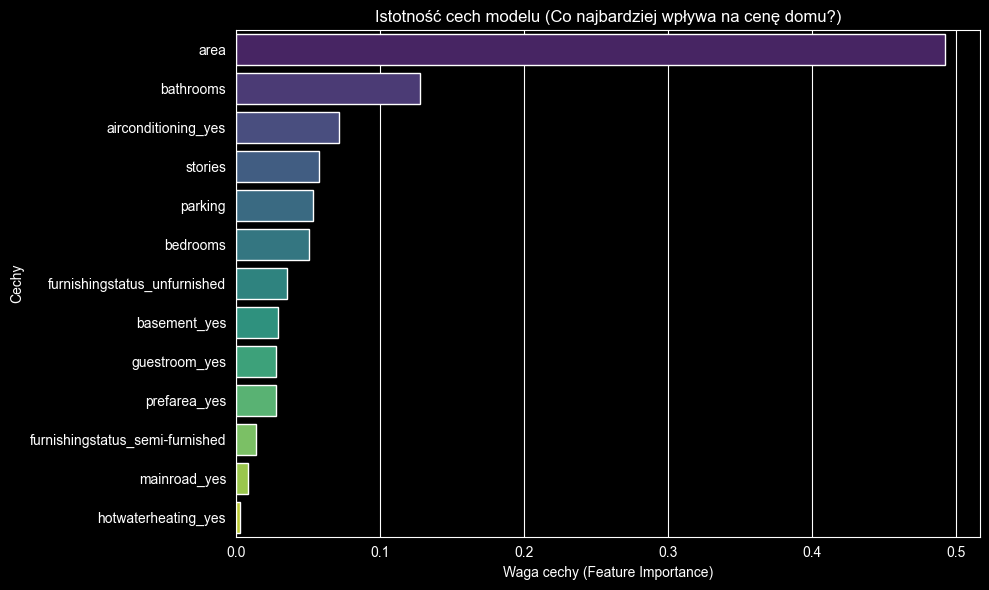

In [24]:
importances = model.feature_importances_
cechy = X_scaled.columns

importance_df = pd.DataFrame({'Cecha': cechy, 'Istotnosc': importances})
importance_df = importance_df.sort_values(by='Istotnosc', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Istotnosc', y='Cecha', data=importance_df, hue='Cecha', palette='viridis', legend=False)
plt.title('Istotność cech modelu (Co najbardziej wpływa na cenę domu?)')
plt.xlabel('Waga cechy (Feature Importance)')
plt.ylabel('Cechy')
plt.tight_layout()
plt.show()